# Notebook 01v4: Synthetic Experiment — Author Condition Matching Sweep

**目的**: 著者Rebuttal条件（1000サンプル、dim=1024、λ=0.01、MCC=0.85）を再現する。

不明パラメータを網羅的にsweep:
- Phase 1: ベースライン
- Phase 2: AE構成sweep（活性化×層数×hidden dim = 12パターン）
- Phase 3: B_true非ゼロ率sweep
- Phase 4: Learning rate sweep
- Phase 5: 非線形混合

成功基準: **MCC > 0.75**

In [4]:
import os, sys, subprocess
REPO = 'thoughtcomm'
if os.path.exists(REPO):
    os.chdir(REPO)
    subprocess.run(['git', 'pull', 'origin', 'main'], check=True)
else:
    subprocess.run(['git', 'clone', 'https://github.com/AUMEZAK/thoughtcomm.git'], check=True)
    os.chdir(REPO)
    subprocess.run(['pip', 'install', '-e', '.', '-q'], check=True)

In [5]:
# Run the full sweep script
exec(open('tests/experiments/test_synthetic_v4_sweep.py').read())

Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Phase 1: Baseline (dim=1024, n=1000, λ=0.01)
  Epoch 50/200: rec=0.0311, jac=0.0066
  Epoch 100/200: rec=0.0291, jac=0.0073
  Epoch 150/200: rec=0.0313, jac=0.0079
  Epoch 200/200: rec=0.0137, jac=0.0084
  MCC = 0.1507 (B nonzero = 66.65%, 97s)

Phase 2: AE architecture sweep
    ep100/200    ep200/200
  leakyrelu    L=2 H=1024  MCC=0.1444  (69s)
    ep100/200    ep200/200
  leakyrelu    L=2 H=2048  MCC=0.1448  (69s)
    ep100/200    ep200/200
  leakyrelu    L=3 H=1024  MCC=0.1557  (90s)
    ep100/200    ep200/200
  leakyrelu    L=3 H=2048  MCC=0.1507  (94s)
    ep100/200    ep200/200
  gelu         L=2 H=1024  MCC=0.1436  (76s)
    ep100/200    ep200/200
  gelu         L=2 H=2048  MCC=0.1449  (75s)
    ep100/200    ep200/200
  gelu         L=3 H=1024  MCC=0.1527  (105s)
    ep100/200    ep200/200
  gelu         L=3 H=2048  MCC=0.1292  (107s)
    ep100/200    ep200/200
  relu         L=2 H=1024  MCC=0.1441  (69s)
    ep100/200    ep200/200
  rel

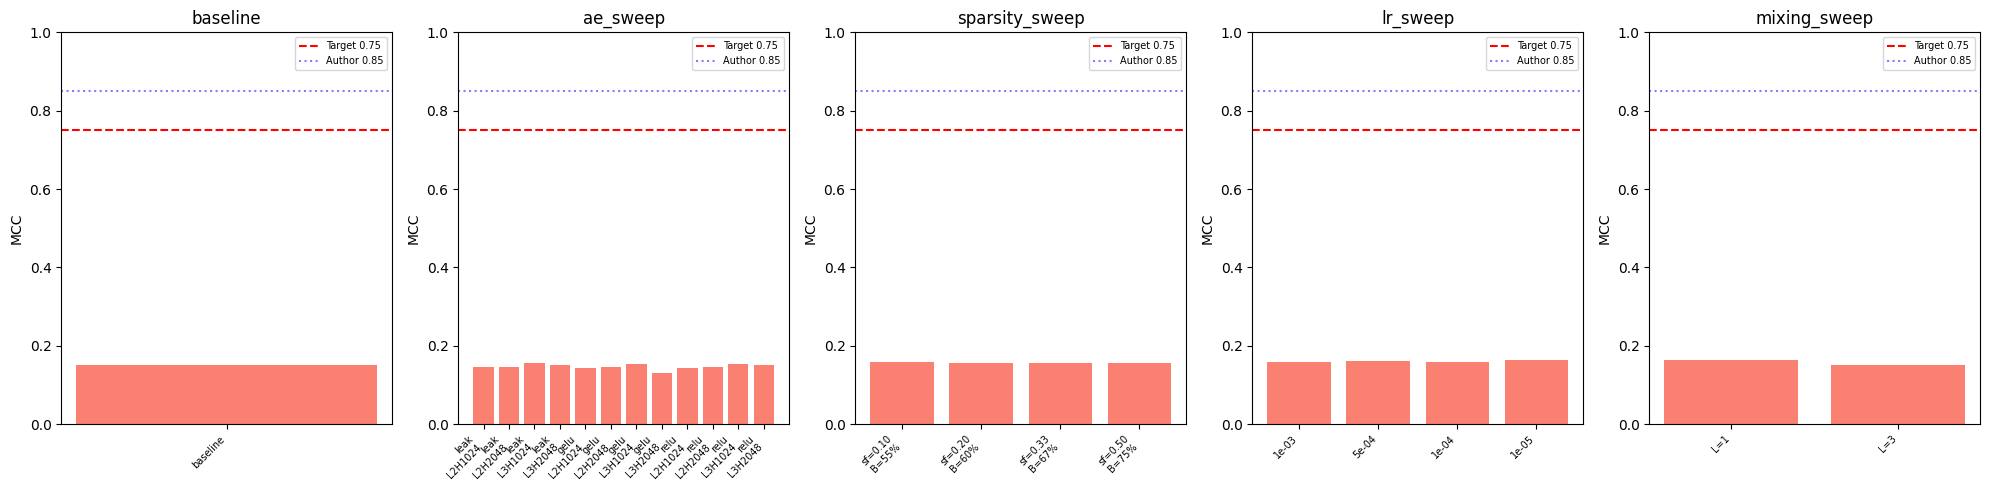


Best MCC: 0.1640
Config: leakyrelu L=3 H=1024 sf=0.10 lr=1e-05 mix_L=1


In [8]:
# Visualize results
import json
import matplotlib.pyplot as plt

with open('results/synthetic_v4_sweep.json') as f:
    results = json.load(f)

# Plot MCC by phase
phases = {}
for r in results:
    p = r['phase']
    if p not in phases:
        phases[p] = []
    phases[p].append(r)

fig, axes = plt.subplots(1, len(phases), figsize=(4*len(phases), 5))
if len(phases) == 1:
    axes = [axes]

for ax, (phase, rs) in zip(axes, phases.items()):
    mccs = [float(r['mcc']) for r in rs] # Convert MCC to float here
    labels = []
    for r in rs:
        if phase == 'ae_sweep':
            labels.append(f"{r['ae_activation'][:4]}\nL{r['ae_layers']}H{r['ae_hidden']}")
        elif phase == 'sparsity_sweep':
            labels.append(f"sf={r['shared_fraction']:.2f}\nB={r['b_nonzero_frac']:.0%}")
        elif phase == 'lr_sweep':
            labels.append(f"{r['lr']:.0e}")
        elif phase == 'mixing_sweep':
            labels.append(f"L={r['mixing_layers']}")
        else:
            labels.append('baseline')

    bars = ax.bar(range(len(mccs)), mccs, color=['green' if m > 0.75 else 'salmon' for m in mccs])
    ax.axhline(y=0.75, color='red', linestyle='--', label='Target 0.75')
    ax.axhline(y=0.85, color='blue', linestyle=':', alpha=0.5, label='Author 0.85')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    ax.set_title(phase)
    ax.set_ylim(0, 1)
    ax.set_ylabel('MCC')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('results/01v4_synthetic_sweep.png', dpi=150)
plt.show()

# Print best
best = max(results, key=lambda r: float(r['mcc'])) # Also convert here for finding max
print(f"\nBest MCC: {float(best['mcc']):.4f}")
print(f"Config: {best['ae_activation']} L={best['ae_layers']} H={best['ae_hidden']} "
      f"sf={best['shared_fraction']:.2f} lr={best['lr']} mix_L={best['mixing_layers']}")